In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

In [6]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv('wine_quality/winequality-white.csv', sep=";")

print(df.quality.value_counts())
df.shape
df.info()
df.dtypes

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
df.isnull().sum() 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

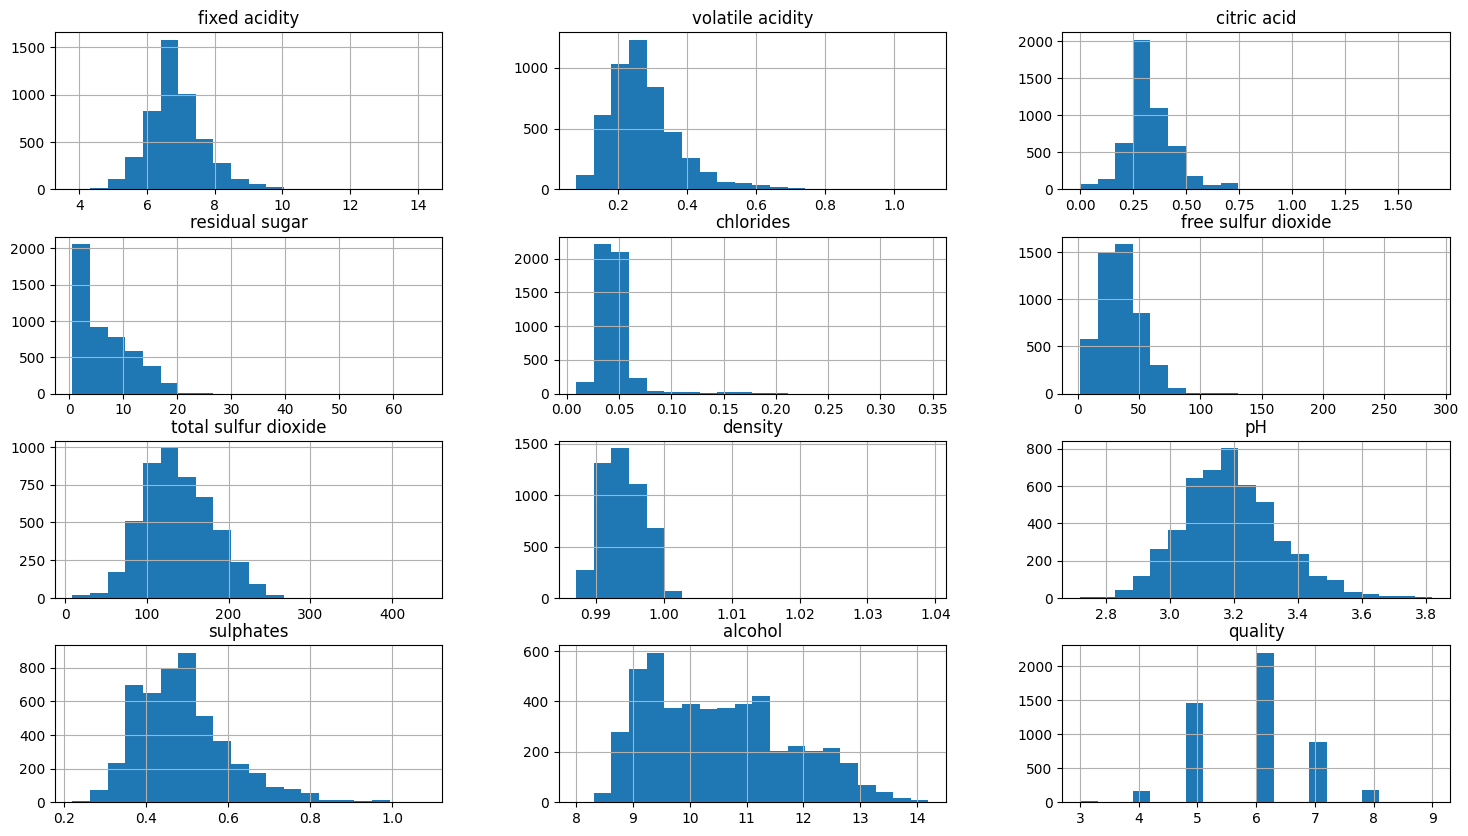

In [9]:
df.hist(figsize=(18, 10), bins=20);

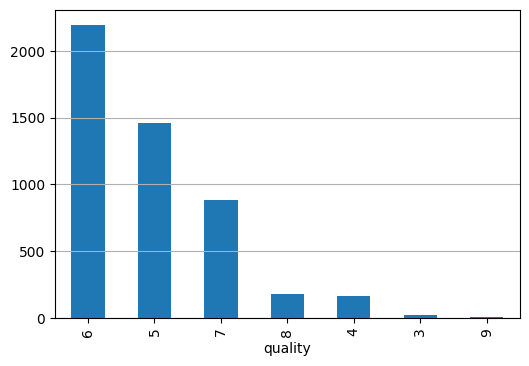

In [10]:
df['quality'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')
plt.show()

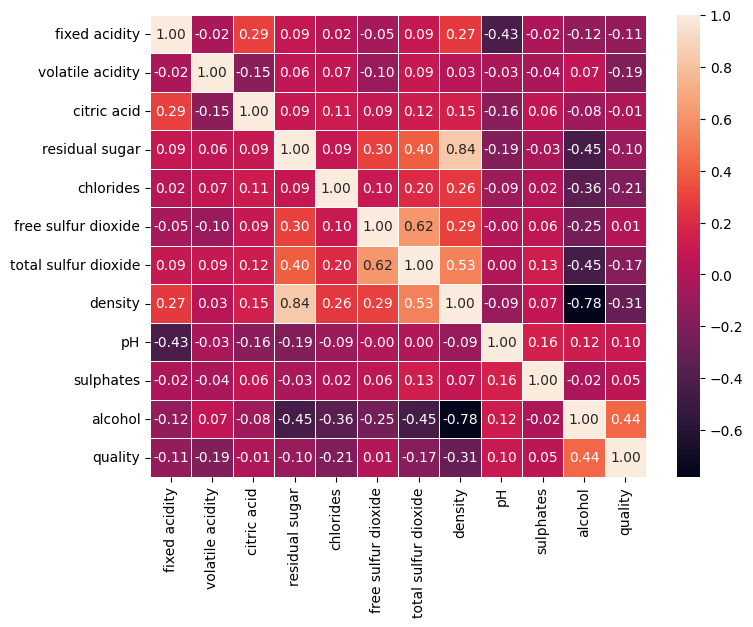

In [11]:
#correlation map
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cbar=True, linewidths=.5, fmt= '.2f')
plt.show()

#Выбрал самые сильные зависимости для качества

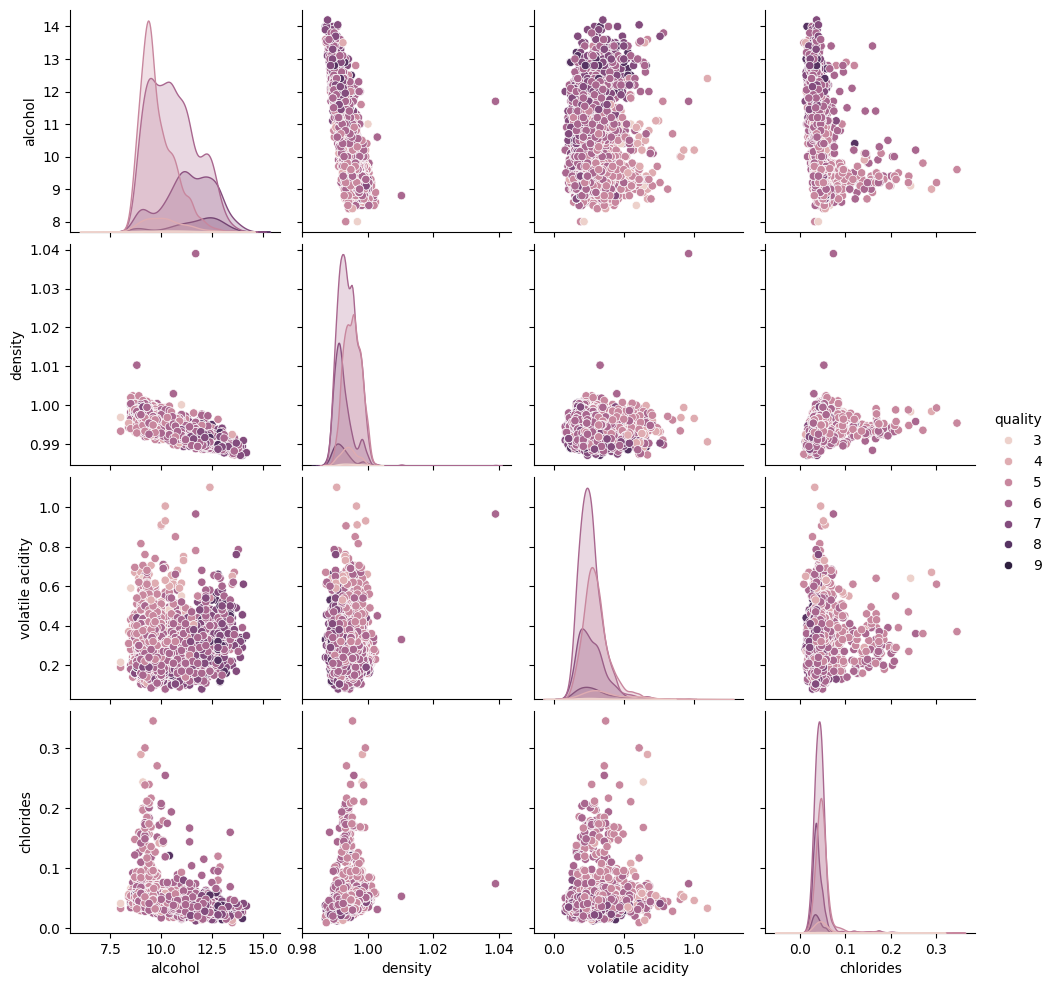

In [12]:
sns.pairplot(df[['alcohol','density','volatile acidity','chlorides','quality']], hue='quality')

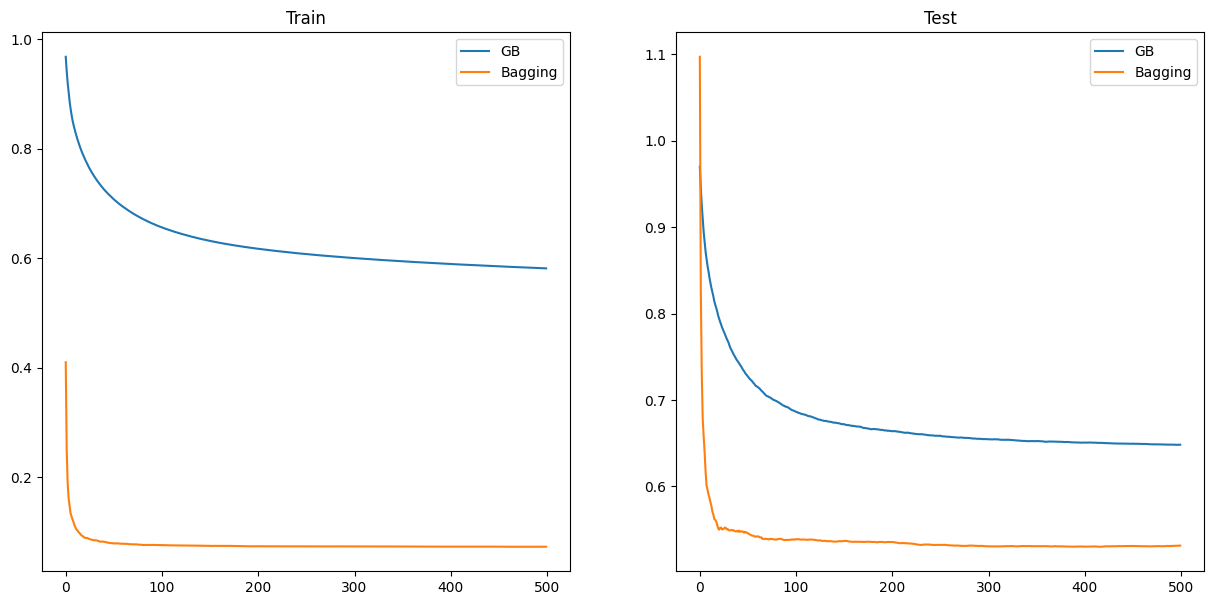

In [13]:
X = df.drop('quality', axis=1)
Y = df['quality']  
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.5, test_size=0.5)

MAX_ESTIMATORS = 500

# BAGGING
br = BaggingRegressor(warm_start=True)
err_train_bag = []
err_test_bag = []
for i in range(1, MAX_ESTIMATORS+1):
    br.n_estimators = i
    br.fit(X_train, Y_train)
    err_train_bag.append(1 - br.score(X_train, Y_train))
    err_test_bag.append(1 - br.score(X_test, Y_test))

# GB
gbclf = GradientBoostingRegressor(warm_start=True, max_depth=1, learning_rate=0.1)
err_train_gb = []
err_test_gb = []
for i in range(1, MAX_ESTIMATORS+1):
    gbclf.n_estimators = i
    gbclf.fit(X_train, Y_train)
    err_train_gb.append(1 - gbclf.score(X_train, Y_train))
    err_test_gb.append(1 - gbclf.score(X_test, Y_test))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(err_train_gb, label='GB')
plt.plot(err_train_bag, label='Bagging')
plt.legend()
plt.title('Train')
plt.subplot(1, 2, 2)
plt.plot(err_test_gb, label='GB')
plt.plot(err_test_bag, label='Bagging')
plt.legend()
plt.title('Test')
plt.gcf().set_size_inches(15,7)

#Bagging справляется лучше на данной задаче

In [14]:
min(err_test_bag), min(err_test_gb)

(0.53027088434468, 0.6481508256524087)

In [15]:
np.argmin(err_test_gb), np.argmin(err_test_bag),

(np.int64(496), np.int64(418))

In [16]:
X = df.drop('quality', axis=1).values
y = df['quality'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=241)

In [17]:
y_test

array([6, 7, 7, 5, 6, 5, 7, 6, 6, 5, 5, 5, 5, 6, 6, 7, 7, 5, 5, 6, 5, 8,
       5, 5, 5, 6, 6, 6, 7, 5, 5, 6, 7, 6, 5, 7, 6, 6, 5, 7, 6, 6, 6, 7,
       6, 5, 6, 7, 6, 6, 6, 6, 6, 5, 5, 7, 6, 5, 7, 6, 7, 5, 5, 6, 6, 6,
       6, 5, 7, 6, 5, 6, 6, 4, 6, 6, 4, 7, 6, 6, 3, 6, 8, 7, 6, 4, 6, 6,
       7, 7, 6, 7, 6, 7, 6, 5, 6, 5, 7, 5, 6, 6, 6, 8, 6, 5, 6, 7, 5, 6,
       6, 5, 5, 7, 6, 6, 7, 5, 6, 6, 7, 6, 6, 6, 7, 6, 5, 7, 5, 6, 6, 6,
       5, 5, 6, 6, 6, 7, 5, 5, 7, 5, 4, 6, 7, 5, 5, 8, 7, 8, 6, 6, 5, 6,
       5, 6, 4, 5, 7, 6, 6, 5, 6, 6, 5, 7, 7, 6, 6, 7, 6, 5, 6, 5, 5, 6,
       7, 7, 6, 8, 6, 5, 5, 7, 4, 6, 4, 7, 7, 6, 5, 5, 6, 7, 9, 6, 5, 6,
       6, 5, 6, 7, 6, 5, 5, 7, 6, 6, 6, 6, 5, 7, 5, 7, 5, 7, 6, 5, 6, 5,
       6, 5, 6, 7, 7, 7, 7, 7, 3, 4, 7, 6, 7, 6, 5, 6, 5, 7, 6, 5, 5, 6,
       6, 6, 5, 5, 5, 7, 5, 5, 5, 5, 6, 7, 6, 4, 5, 6, 6, 7, 5, 7, 7, 4,
       6, 6, 6, 5, 5, 6, 6, 7, 7, 6, 6, 7, 6, 5, 5, 6, 7, 6, 5, 5, 6, 8,
       5, 7, 7, 5, 7, 7, 9, 6, 5, 6, 5, 6, 5, 6, 6,

In [18]:
%%time
gbm = GradientBoostingClassifier(n_estimators=250, learning_rate=0.2, verbose=True).fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.1904            9.01s
         2           1.1312            8.02s
         3           1.0916            7.42s
         4           1.0613            7.03s
         5           1.0354            6.83s
         6           1.0105            6.65s
         7           0.9905            6.47s
         8           0.9738            6.34s
         9           0.9601            6.25s
        10           0.9459            6.15s
        20           0.8549            5.64s
        30           0.7976            5.30s
        40           0.7511            5.01s
        50           0.7045            4.77s
        60           0.6686            4.53s
        70           0.6377            4.28s
        80           0.6053            4.04s
        90           0.5765            3.80s
       100           0.5505            3.56s
       200           0.3608            1.10s
CPU times: user 5.34 s, sys: 60.8 ms, total: 5.4 s
Wal

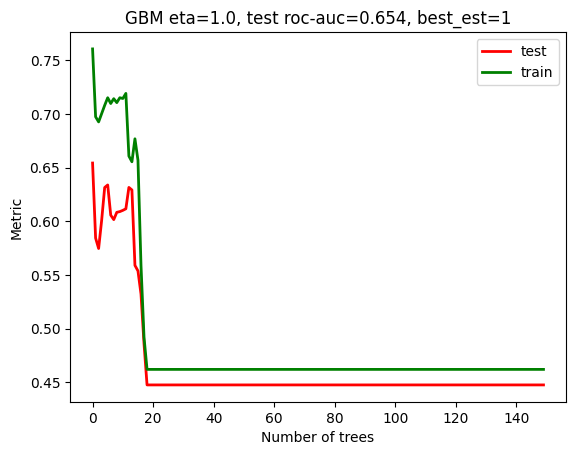

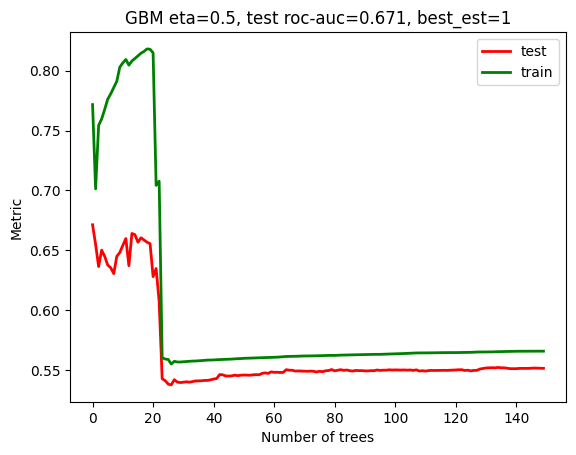

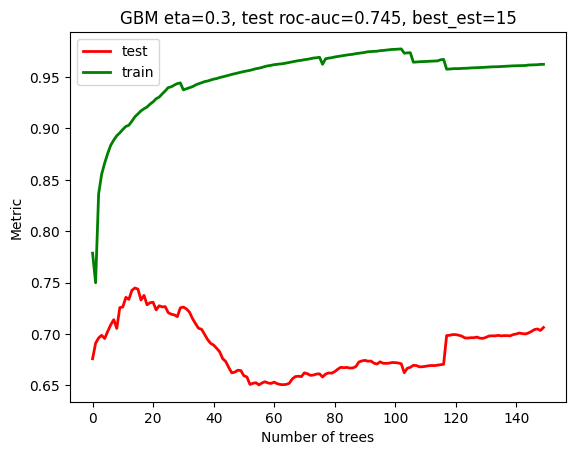

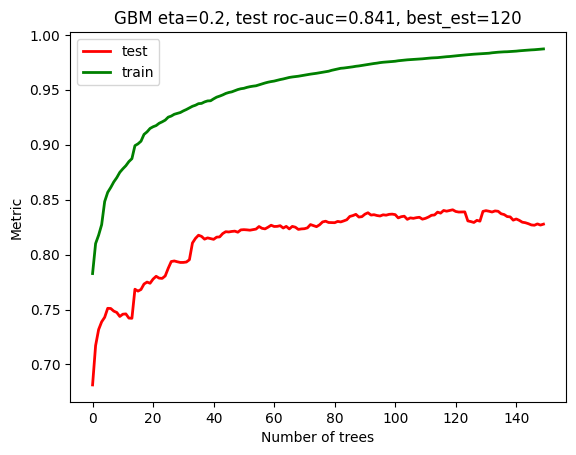

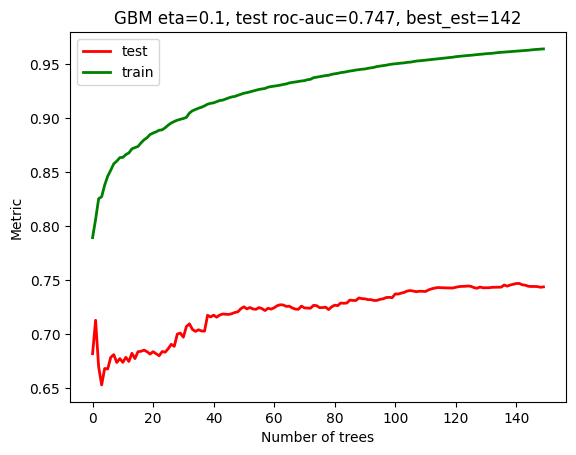

In [21]:
from sklearn.metrics import roc_auc_score

for learning_rate in [1, 0.5, 0.3, 0.2, 0.1]:

    gbm = GradientBoostingClassifier(n_estimators=150, learning_rate=learning_rate, random_state=241).fit(X_train, y_train)

    test_deviance = np.zeros(gbm.n_estimators)
    for i, proba in enumerate(gbm.staged_predict_proba(X_test)):
        test_deviance[i] = roc_auc_score(y_test, proba, multi_class='ovr')

    train_deviance = np.zeros(gbm.n_estimators)
    for i, proba in enumerate(gbm.staged_predict_proba(X_train)):
        train_deviance[i] = roc_auc_score(y_train, proba, multi_class='ovr')

    plt.figure()
    plt.plot(test_deviance, 'r', linewidth=2)
    plt.plot(train_deviance, 'g', linewidth=2)
    plt.legend(['test', 'train'])
    plt.title('GBM eta=%.1f, test roc-auc=%.3f, best_est=%d' % (learning_rate, test_deviance.max(), test_deviance.argmax()+1))
    plt.xlabel('Number of trees')
    plt.ylabel('Metric')

In [27]:
from sklearn.metrics import roc_auc_score
rf = RandomForestClassifier(n_estimators=24, random_state=0).fit(X_train, y_train)
print('Train RF ROC-AUC =', roc_auc_score(y_train, rf.predict_proba(X_train), multi_class='ovr'))
print('Test RF ROC-AUC = ', roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr'))

Train RF ROC-AUC = 0.9999992933310541
Test RF ROC-AUC =  0.8086315324448216


In [28]:
! pip install lightgbm
! pip install catboost

In [29]:
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

In [30]:
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_surface(X, y, clf):
    h = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 8))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

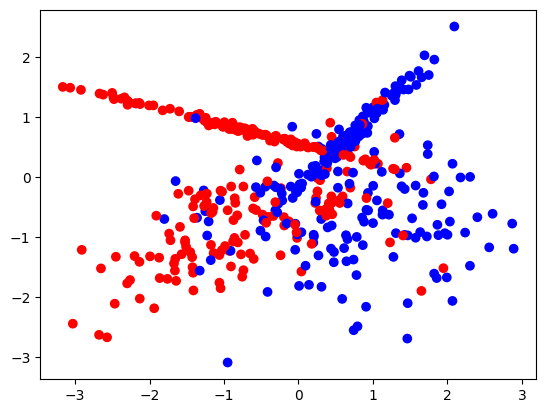

In [31]:
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0,
                           n_classes=2, n_clusters_per_class=2,
                           flip_y=0.05, class_sep=0.8, random_state=241)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold);

In [64]:
from sklearn.metrics import *
from catboost import CatBoostClassifier

0.9200746799431011


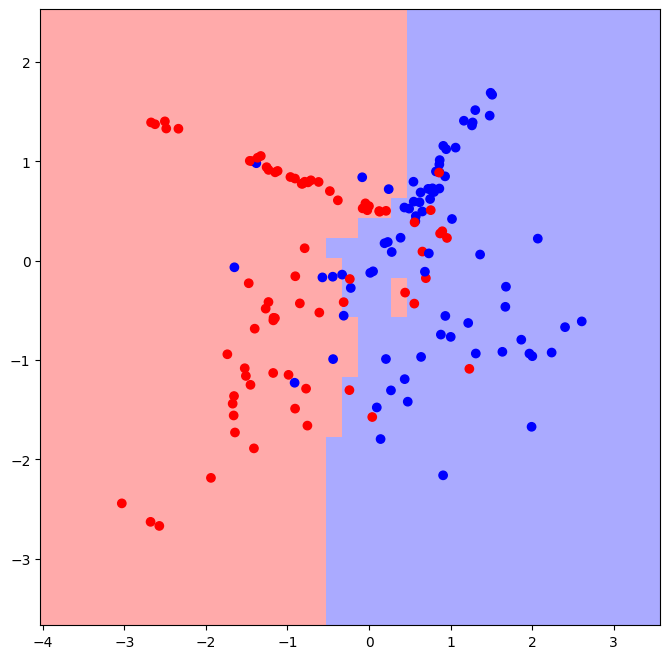

In [67]:
clf = CatBoostClassifier(logging_level='Silent', learning_rate=0.01, iterations=200)
clf.fit(X_train, y_train)
plot_surface(X_test, y_test, clf)

print(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

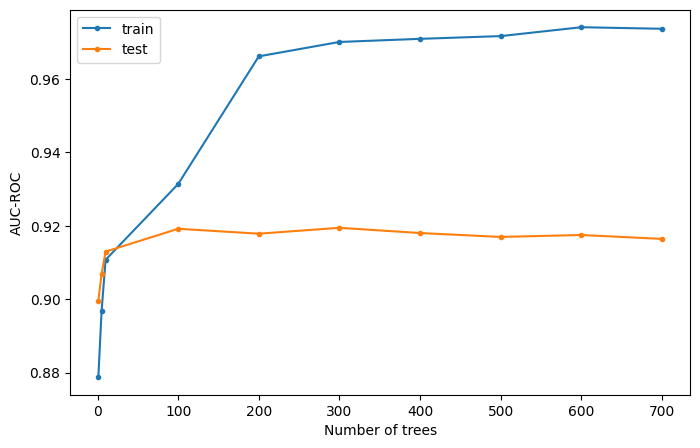

In [68]:
n_trees = [1, 5, 10, 100, 200, 300, 400, 500, 600, 700]
quals_train = []
quals_test = []
for n in n_trees:
    clf = CatBoostClassifier(iterations=n, logging_level='Silent')
    clf.fit(X_train, y_train)
    q_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    q_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_train.append(q_train)
    quals_test.append(q_test)

plt.figure(figsize=(8, 5))
plt.plot(n_trees, quals_train, marker='.', label='train')
plt.plot(n_trees, quals_test, marker='.', label='test')
plt.xlabel('Number of trees')
plt.ylabel('AUC-ROC')
plt.legend()

plt.show()

In [69]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(n_estimators=300, verbose=-1)
clf.fit(X_train, y_train)
plot_surface(X_test, y_test, clf)

print(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

OSError: dlopen(/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <59CCDAC2-EBAE-32F7-ADF4-469B834532C9> /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)